# Tarea Semanal 6
## Autor: Pedro Guzman


## Consigna 
En el repositorio [PDStestbench](#) encontrará tres tipos de señales registradas:

- **Electrocardiograma (ECG).** En el archivo **ECG_TP4.mat** encontrará un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.
- **Pletismografía (PPG).** El archivo PPG.csv contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.
- **Audio**. Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.

Los detalles de cómo acceder a dichos registros los pueden encontrar en [lectura_sigs.py](#)

Se pide:

**1)** Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

2) Realice una estimación del ancho de banda de cada señal y presente los resultados en una tabla para facilitar la comparación.

Bonus:

- 💎 Proponga algún tipo de señal que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.
 



## Solucion Propuesta

Se realizan varias funciones de manera de poder cada señal de distinta fuente de manera rapida y eficaz, sin importar la procedencia de la señal.

En Blacman-Tukey saque la Autocorrelacion utilizando la FFT debido a que si utilizo la autocorrelacion mediante el uso la funcion np.correlate, ya que si no la computadora sufria con la cantidad de operaciones realizadas para sacar la autocorrelacion

https://gist.github.com/ajkluber/f293eefba2f946f47bfa
https://dsp.stackexchange.com/questions/70152/computing-autocorrelation-via-fft
https://dsp.stackexchange.com/questions/98071/autocorrelation-via-fft
https://stackoverflow.com/questions/3949324/calculate-autocorrelation-using-fft-in-matlab

Se ve que en muchos casos se usa Zero Padding para hacer laa autocorrelacion VIA FFT, en este caso no hace falta debido a que los lags menores a N/2 no se corrompen, es como si fuera un Aliasing Circular, pero no nos afecta debido a que agarramos 1<M<N//5 

In [1]:
from scipy.io import wavfile, loadmat, whosmat
import numpy as np
from scipy.signal import windows as win
import matplotlib.pyplot as plt
import scipy.signal as sp



def blackman_tukey(x, fs=1, M=None, window='blackman', Np=None):
    """
    Estima la Densidad Espectral de Potencia (PSD) usando el método de Blackman-Tukey.
    
    El método consiste en:
        1. Calcular la autocorrelación de la señal (via FFT para eficiencia)
        2. Truncar la autocorrelación a M lags
        3. Aplicar una ventana sobre la autocorrelación truncada
        4. Calcular la FFT de la autocorrelación ventaneada
    
    Args:
        x      : señal de entrada (array 1D o 2D, se aplana automáticamente)
        fs     : frecuencia de muestreo en Hz (default: 1)
        M      : número de lags de la autocorrelación. Controla el balance entre
                 resolución frecuencial (M grande) y varianza del estimador (M chico).
                 Default: N//5
        window : ventana a aplicar sobre la autocorrelación. Cualquier ventana
                 válida de scipy.signal.windows (default: 'blackman')
        Np      : Zero Padding para la ultima fft
    
    Returns:
        f_half   : array de frecuencias positivas [0, fs/2] en Hz
        psd_half : array con la PSD estimada en V²/Hz
    """
    # Aplanar a 1D y convertir a float64 para evitar overflow en operaciones
    x = x.ravel().astype(float)
    N = len(x)

    if M is None:
        M = N // 5

    if Np is None:
        Np = N
    # --- Autocorrelación via FFT ---
    # Equivalente a np.correlate(x, x, mode='full') pero O(N log N) en vez de O(N²)
    # Dividimos por (N * fs) para normalizar: N por el largo de la señal, fs para
    # que el resultado quede en unidades de V²/Hz al integrar
    X = np.fft.fft(x)
    xcorr_full = np.fft.ifft(X * np.conj(X)).real / (N * fs)

    # --- Truncado a M lags ---
    # xcorr_full[0]       = lag 0
    # xcorr_full[1..M-1]  = lags positivos 1 a M-1
    # xcorr_full[N-M+1..] = lags negativos -(M-1) a -1 (por periodicidad de la FFT)
    # Armamos el vector simétrico: [-(M-1), ..., 0, ..., (M-1)]
    r = np.concatenate([xcorr_full[N-(M-1):], xcorr_full[:M]])

    # --- Ventaneo de la autocorrelación ---
    # La ventana reduce el efecto de los lags extremos (menos confiables por tener
    # menos muestras para promediar), reduciendo el leakage espectral
    ventana = win.get_window(window, len(r))
    r_windowed = r * ventana

    # --- FFT de la autocorrelación ventaneada ---
    # Usamos n=N para que la resolución frecuencial sea fs/N Hz/bin, estaria aplicando Zero Padding
    psd = np.abs(np.fft.fft(r_windowed, n=Np))

    # --- Quedarse solo con frecuencias positivas [0, fs/2] ---
    f = np.fft.fftfreq(N, d=1/fs)
    mitad = f >= 0
    f_half = f[mitad]
    psd_half = psd[mitad]

    # Duplicar frecuencias positivas (excepto DC) para conservar la potencia total,
    # ya que descartamos la mitad negativa del espectro
    psd_half[1:] *= 2

    return f_half, psd_half


def potencia_acumulada(f, psd):
    """
    Calcula la potencia acumulada en función de la frecuencia integrando la PSD.

    Aplica el teorema de Parseval en forma discreta:
        P(f) = sum(PSD[0..f]) * df

    donde df = f[1] - f[0] es el espaciado entre bins de frecuencia.
    El último valor del array resultante es la potencia total de la señal.

    Args:
        f   : array de frecuencias en Hz
        psd : array de PSD en V²/Hz, mismo largo que f

    Returns:
        P_acum : array de potencia acumulada en V², mismo largo que f.
                 P_acum[-1] = potencia total de la señal.
    """
    df = f[1] - f[0]          # espaciado entre bins [Hz]
    P_acum = np.cumsum(psd) * df  # integración discreta (regla del rectángulo)
    return P_acum


def plot_psd(signal, fs, titulo, LIMITSPSD = None, LIMITSPA = None, YLIMITSPSD = None):
    """
    Estima y grafica la PSD de una señal usando 5 métodos, y compara la
    potencia total y el ancho de banda al 99% entre ellos.

    Genera dos figuras:
        1. PSD en escala logarítmica (semilogy) con los 5 métodos superpuestos
        2. Panel comparativo con:
              - Izquierda: potencia acumulada normalizada (0-100%) vs frecuencia,
                           con línea punteada en 99%
              - Derecha:   barras dobles de potencia total [V²] y BW al 99% [Hz]
                           para cada método

    También imprime una tabla resumen con potencia total y BW al 99% por método,
    más la potencia calculada directamente en el dominio del tiempo como referencia.

    Args:
        signal : señal de entrada (array 1D o 2D, se aplana automáticamente)
        fs     : frecuencia de muestreo en Hz
        titulo : string que aparece como título en los gráficos y en el print
    """
    signal = signal.ravel().astype(float)
    N = len(signal)

    # --- Estimación de PSD con cada método ---
    # Welch con segmentos grandes: mejor resolución frecuencial, más varianza
    f1, P1 = sp.welch(signal, fs, window='hann', nperseg=N//5)

    # Welch default (nperseg=256): puede dar mala resolución si fs es baja
    f2, P2 = sp.welch(signal, fs, window='hann')

    # Blackman-Tukey: autocorrelación ventaneada, buen balance sesgo-varianza
    f3, P3 = blackman_tukey(signal, fs=fs)

    f5, P5 = blackman_tukey(signal, M=N//20 , fs=fs)
    
    # Periodograma ventaneado: alta resolución pero alta varianza (ruidoso)
    f4, P4 = sp.periodogram(signal, fs, window='hann')

    metodos = [
        (f4, P4, 'Periodogram'),
        (f3, P3, 'Blackman-Tukey, M=N/5'),
        (f1, P1, 'Welch nperseg=N/5'),
        (f5, P5, 'Blackman-Tukey, M=N//20'),
        (f2, P2, 'Welch default'),
    ]

    # --- Figura 1: PSD ---
    fig, ax = plt.subplots(figsize=(11, 4))
    for f, P, label in metodos:
        ax.semilogy(f, P, label=label)
    ax.set_title(titulo)
    ax.set_xlabel('frequency [Hz]')
    ax.set_ylabel('PSD [V**2/Hz]')

    if LIMITSPSD != None :
        ax.set_xlim(LIMITSPSD)
    if LIMITSPSD != None :
        ax.set_ylim(YLIMITSPSD)
    ax.legend()
    ax.grid()
    plt.show()

    # --- Figura 2: Potencia acumulada comparativa ---
    fig, axes = plt.subplots( figsize=(11, 4))
    fig.suptitle(f'Potencia acumulada - {titulo}')

    P_totales = []
    f_99s = []

    for f, P, label in metodos:
        P_acum = potencia_acumulada(f, P)
        P_total = P_acum[-1]
        # Frecuencia donde se alcanza el 99% de la potencia total (ancho de banda)
        f_99 = f[np.argmax(P_acum >= 0.99 * P_total)]
        P_totales.append(P_total)
        f_99s.append(f_99)
        # Normalizar a porcentaje para comparar métodos con distintas escalas
        axes.plot(f, P_acum / P_total * 100, label=label)

    axes.axhline(99, color='k', linestyle='--', label='99%')
    axes.set_xlabel('Frecuencia [Hz]')
    axes.set_ylabel('Potencia acumulada [%]')
    axes.set_title('Potencia acumulada normalizada')
    if LIMITSPA != None :
        axes.set_xlim(LIMITSPA)
    axes.legend()
    axes.grid()
    plt.show()
    # Barras dobles: potencia total (azul) y BW al 99% (naranja)
    # Usan ejes Y distintos porque tienen unidades diferentes (V² vs Hz)
    labels = [m[2] for m in metodos]
    x = np.arange(len(labels))
    width = 0.35

    fig, axes2 = plt.subplots( figsize=(9, 4))
    fig.suptitle(f'Potencia y BW - {titulo}')
    ax2 = axes2
    ax2.bar(x - width/2, P_totales, width, label='P total [V²]')
    ax2.set_ylabel('Potencia total [V²]')
    ax2.set_title('Potencia total y BW al 99%')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=15, ha='right')
    
    ax2.grid(axis='y')

    ax3 = ax2.twinx()   # segundo eje Y sobre el mismo gráfico
    ax3.bar(x + width/2, f_99s, width, color='orange', label='BW 99% [Hz]')
    ax3.set_ylabel('Ancho de banda 99% [Hz]')
    ax3.legend(loc='upper right')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    # --- Print resumen ---
    # Potencia en tiempo via Parseval: mean(x²), sirve como referencia para
    # verificar que la normalización de la PSD es correcta
    P_tiempo = np.mean(signal**2)
    print(f"\n[{titulo}]  P tiempo = {P_tiempo:.8f} V²")
    print(f"  {'Método':<45} {'P total [V²]':>15} {'BW 99% [Hz]':>12}")
    print(f"  {'-'*75}")
    for (_, _, label), P_tot, f99 in zip(metodos, P_totales, f_99s):
        print(f"  {label:<45} {P_tot:>15.8f} {f99:>12.3f}")

Procedo a abri el archivo de la señal de ECG sin ruido. Me paso que abriendo la que tiene ruido, al tener ruido de continua me tiraba el ancho de banda muy para abajo, porque tenia una señal de continua muy fuerte.

Una vez abierto el archivo procedo a analizarlo con la funcion plot_psd la cual me da todo lo que necesito en graficos y tabla, desde el ancho de banda, a la potencia total, los graficos de PSD y la potencia total acumulada, comparando 5 metodos, viendo sus distintas resoluciones con distintos solapamientos, en periodograma y Welch uso ventana Hann, en Blackman-Tukey utilizo ventana Blackman

### ECG

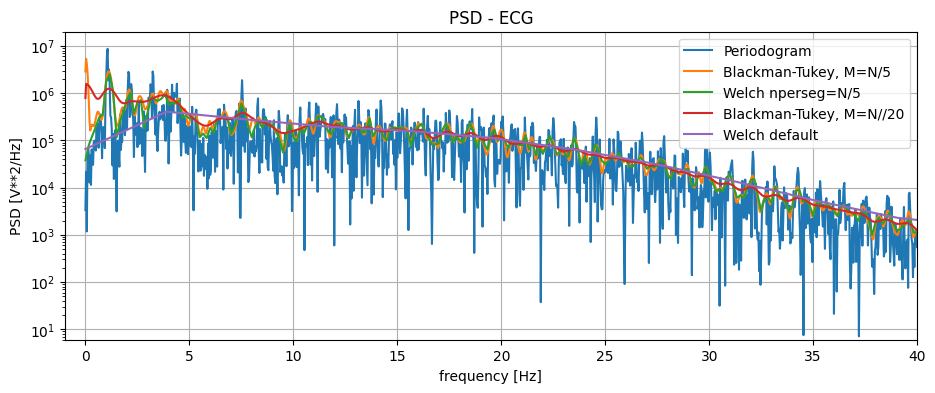

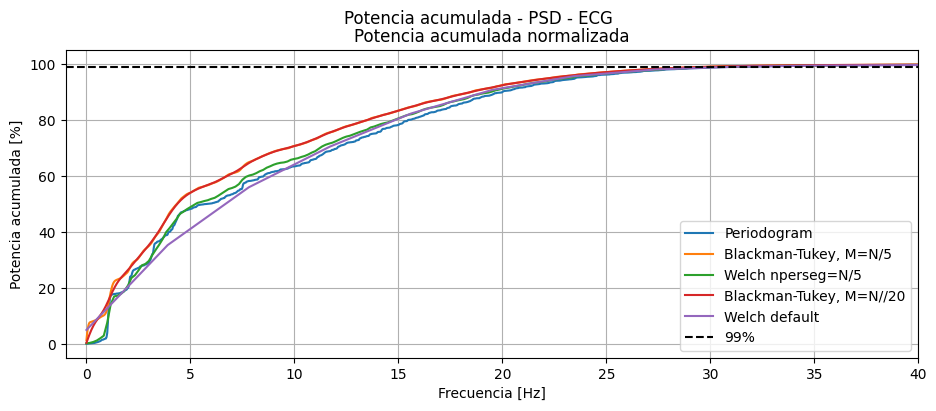

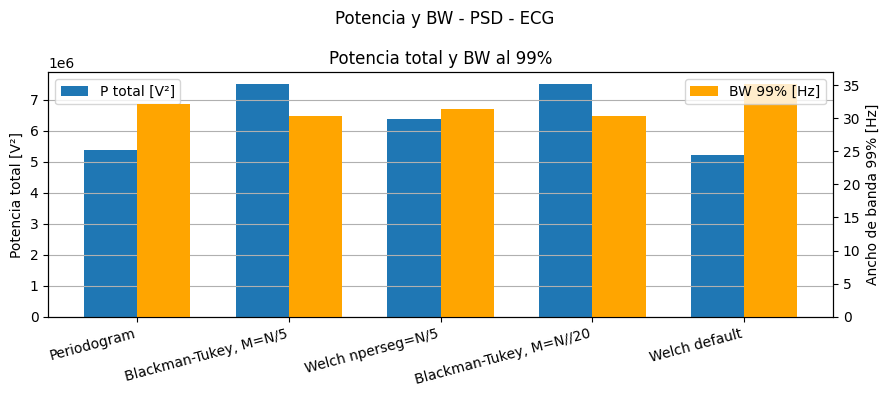


[PSD - ECG]  P tiempo = 7510578.51273333 V²
  Método                                           P total [V²]  BW 99% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                   5365452.87644958       32.067
  Blackman-Tukey, M=N/5                         7510578.33406040       30.333
  Welch nperseg=N/5                             6372159.29449006       31.333
  Blackman-Tukey, M=N//20                       7510575.34073164       30.367
  Welch default                                 5222246.38624862       35.156


In [2]:
# --- MAT ---
fs_mat = 1000 ##Estaba en el archivo de registro
ecg_one_lead = np.load('ecg_sin_ruido.npy')


plot_psd(ecg_one_lead, fs_mat,    'PSD - ECG', [-1, 40],[-1,40],[6e0,2e7] )

Se puede ver como el ancho de banda con cada metodo da un resultado similar, se ve que Welch por Default da un valor mas grande en el ancho de banda, si vemos el grafico de PSD, se puede ver como es la curva mas suave, esto es debido a la cantidad de resolucion que sacrifica. En la estimacion de potencia total, se puede ver como Blackman-Tukey es el que mas se acerca.

Se verifica el ancho de banda del ECG

### PPG

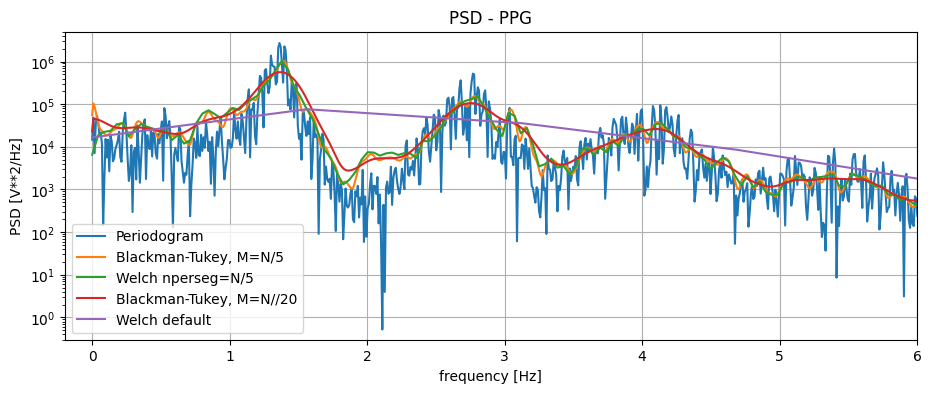

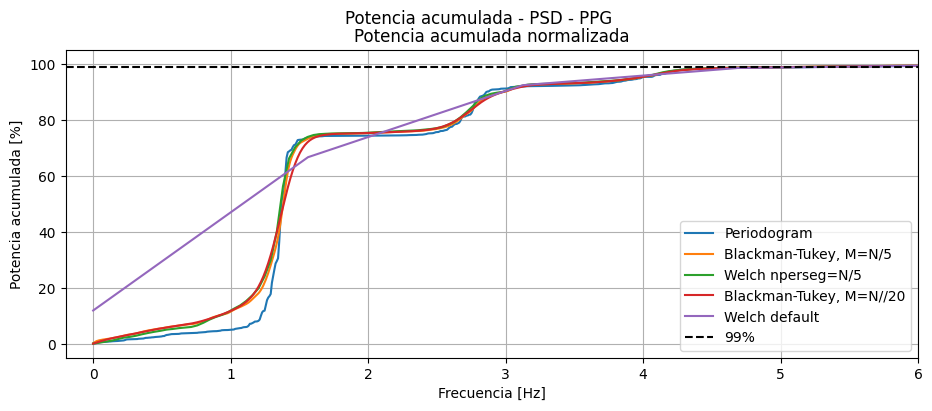

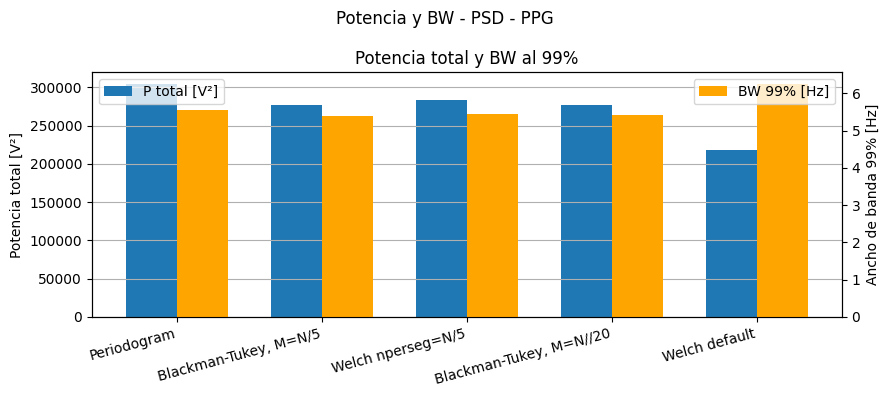


[PSD - PPG]  P tiempo = 276834.57501280 V²
  Método                                           P total [V²]  BW 99% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                   304512.42594689        5.548
  Blackman-Tukey, M=N/5                         276834.57183929        5.396
  Welch nperseg=N/5                             284059.03633395        5.432
  Blackman-Tukey, M=N//20                       276834.53373550        5.405
  Welch default                                 217557.11598099        6.250


In [3]:
ppg = np.load('ppg_sin_ruido.npy')
fs_ppg = 400 ##Estaba en el archivo de registro
plot_psd(ppg,          fs_ppg,    'PSD - PPG', [-0.2, 6],[-0.2, 6],[3e-1,5e6] )

Idem caso anterior, se estima bien el ancho de banda con cada metodo, pero la potencia total la determina mejor Blackman Tukey, pero el Welch con nperseg = N/5 tambien se acerca bastante bien al valor, reducimos la varianza del estimador, pero perdemos resolucion, hay que tener cuidado entre la perdida de resolucion y la varianza, porque la propia perdida de resolucion me insesgar bastante el estimador, debido a que podemos no ver componentes frecuenciales, el ancho de banda cumple con la que se espera con un PPG. 

En la imagen se puede ver como Welch Default es un estimador desastrozo debido a la gran perdida de resolucion espectral

### SILBIDO

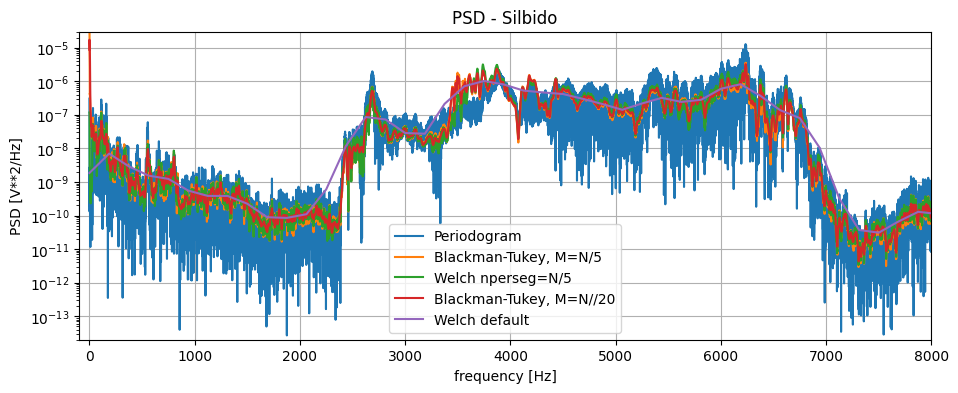

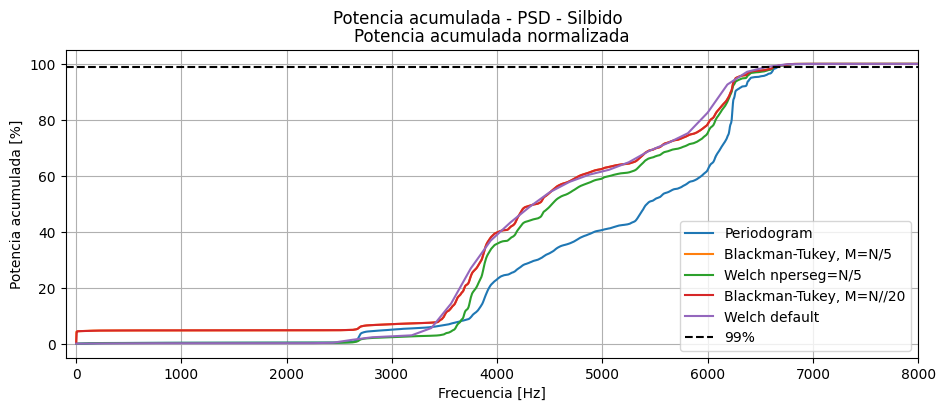

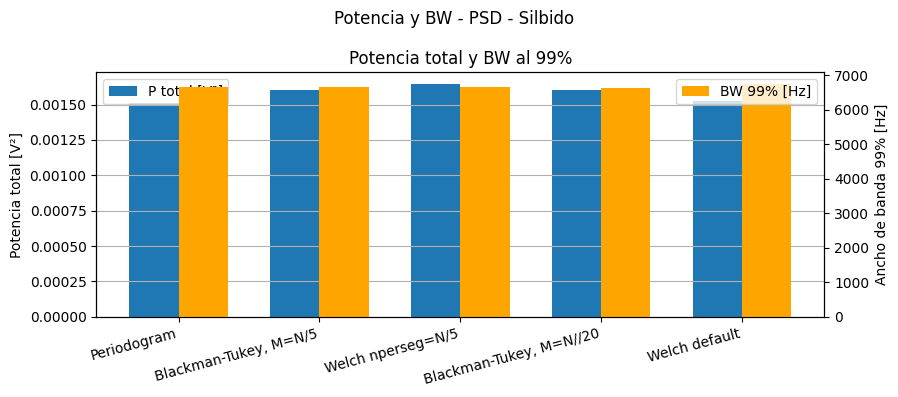


[PSD - Silbido]  P tiempo = 0.00160055 V²
  Método                                           P total [V²]  BW 99% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                        0.00151178     6670.667
  Blackman-Tukey, M=N/5                              0.00160055     6648.000
  Welch nperseg=N/5                                  0.00164570     6655.000
  Blackman-Tukey, M=N//20                            0.00160055     6647.333
  Welch default                                      0.00152822     6750.000


In [4]:
# --- WAVs ---
fs_silbido, silbido     = wavfile.read('silbido.wav')
plot_psd(silbido,      fs_silbido,    'PSD - Silbido', [-100, 8e3],[-100, 8e3],[2e-14,3e-5] )

El silbido es esperable que este en frecuencias mas altas que la señal de audio de voz, debido a que es un tono mas agudo, por lo tanto es frecuencia mas alta, es esperable que su ancho de banda pasabajos sea alto. En este caso todos los estimadores estiman bastante bien el ancho de banda, y la potencia total, pareciera que para señales de audio cualquier estimador funciona correctamente. El que es superior obviamente es el Blackman-Tukey

Pasa lo mismo que en el anterior caso con Welch por fefault, pierde gran parte de resolucion espectral. En el caso de Periodogram se ve que se pierde una gran cantidad de potencai total debido a la varianza de la misma, tiene mucho ruido en si.

### CUCARACHA

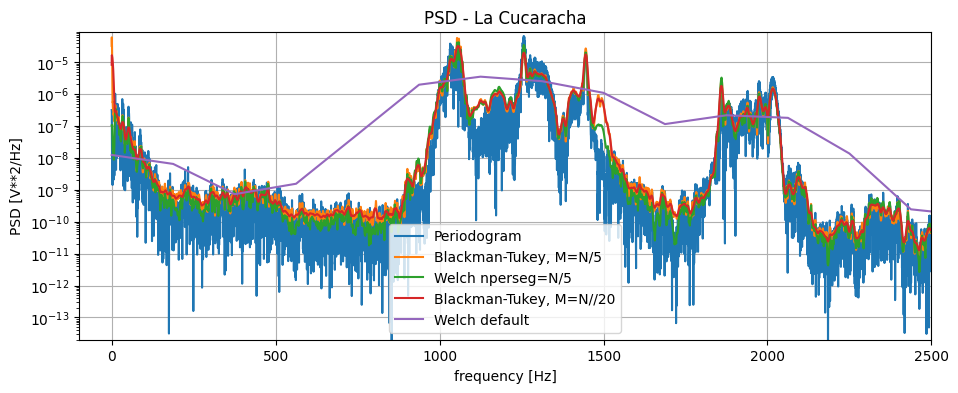

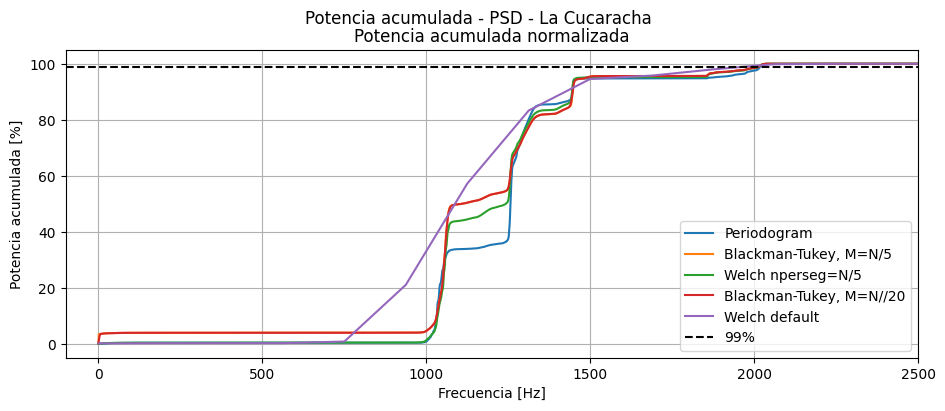

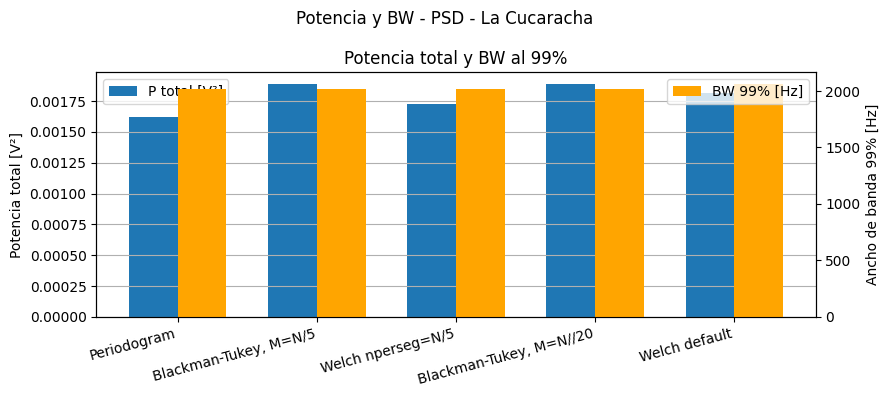


[PSD - La Cucaracha]  P tiempo = 0.00188961 V²
  Método                                           P total [V²]  BW 99% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                        0.00162443     2019.333
  Blackman-Tukey, M=N/5                              0.00188961     2014.333
  Welch nperseg=N/5                                  0.00172984     2015.000
  Blackman-Tukey, M=N//20                            0.00188961     2014.000
  Welch default                                      0.00182005     2062.500


In [5]:
fs_cucaracha, cucaracha = wavfile.read('la cucaracha.wav')


plot_psd(cucaracha,    fs_cucaracha,  'PSD - La Cucaracha', [-100, 2.5e3],[-100, 2.5e3],[2e-14,9e-5] )

Idem inciso anterior.

Welch por default pierde mucha resolucion espectral

### PRUEBA PSD

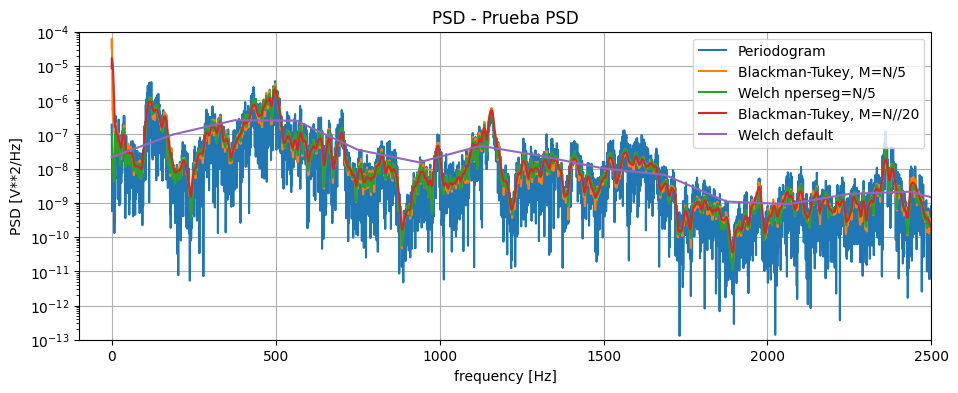

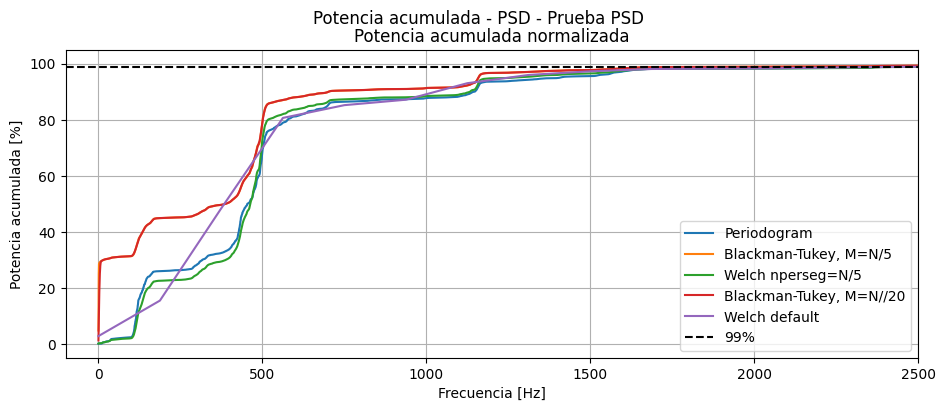

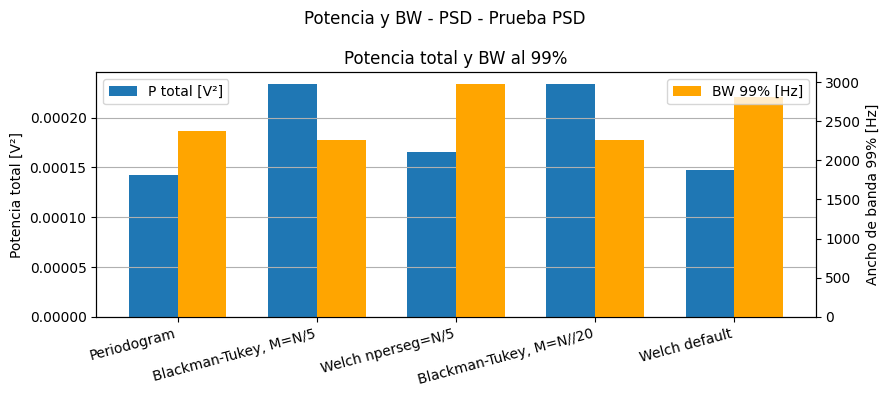


[PSD - Prueba PSD]  P tiempo = 0.00023377 V²
  Método                                           P total [V²]  BW 99% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                        0.00014287     2380.333
  Blackman-Tukey, M=N/5                              0.00023377     2262.667
  Welch nperseg=N/5                                  0.00016575     2975.000
  Blackman-Tukey, M=N//20                            0.00023377     2262.333
  Welch default                                      0.00014711     2812.500


In [6]:
fs_prueba, prueba_psd   = wavfile.read('prueba psd.wav')
plot_psd(prueba_psd,   fs_prueba,     'PSD - Prueba PSD', [-100, 2.5e3],[-100, 2.5e3] ,[1e-13,1e-4] )

Idem inciso anterior. Aca se ve como hay mayor dispersion en los valores de potencia total frente a Blackman Tukey, el mejor estimador vendria a ser este, y es el que nos da un ancho de banda pasa bajos mas chico


Welch por default pierde mucha resolucion espectral

### Bonus Señal de Telefono

La señal de este bonus es una señal de discado de telefono de la letra Numero 1, la misma la tenia desde que curse la materia de medidas e hicimos la calibracion del discado del telefono y verificacion del cumplimiento de la norma. El ensayo del discado del telefono se hizo siguiendo lo desarrollado por la Norma técnica CNC-St2-44.01 V02.1.1 secciones 13 (Condiciones de ensayo), 14.1 (Puentes de alimentación) y 21.2 (Marcación multifrecuente).

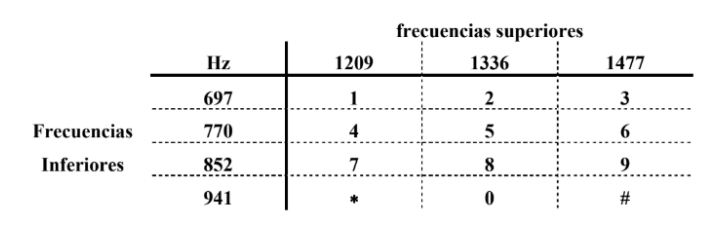

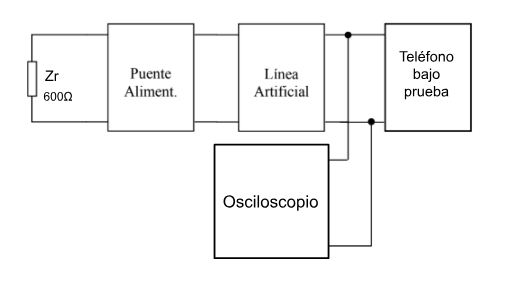

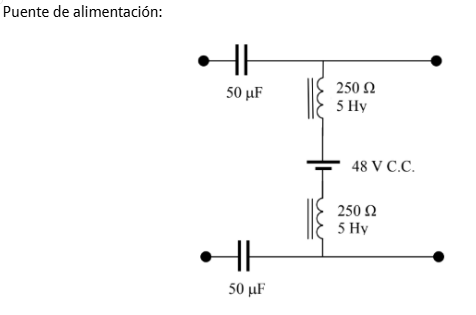

La señal fue digitalizada mediante el ADC del osciloscopio y su respectiva frecuencia de muestreo a una determinada base de tiempo, se pulso la tecla del telefono hasta tener todos los datos en la memoria del osciloscopio y despues se extrajo la señal utilizando un USB para obtener el archivo .CSV, se repitio lo mismo para cad tecla en este caso solo utilizamos la tecla NUM 1

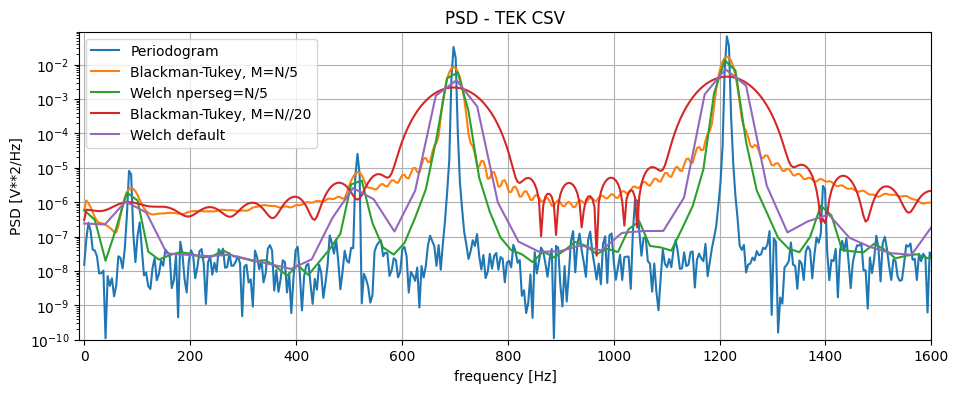

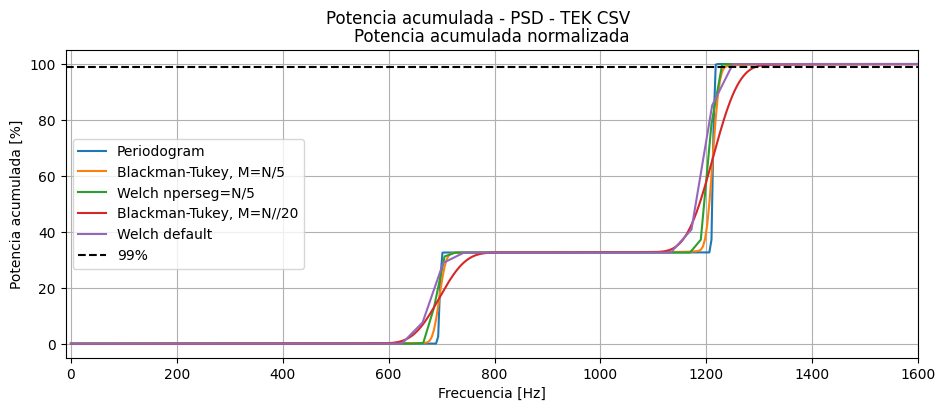

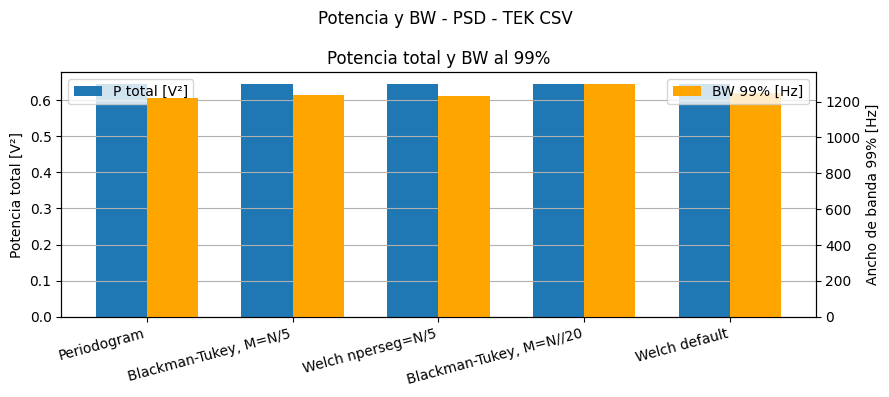


[PSD - TEK CSV]  P tiempo = 0.64439597 V²
  Método                                           P total [V²]  BW 99% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                        0.64445977     1217.742
  Blackman-Tukey, M=N/5                              0.64439554     1237.903
  Welch nperseg=N/5                                  0.64423677     1229.839
  Blackman-Tukey, M=N//20                            0.64459228     1298.387
  Welch default                                      0.64440692     1250.000


In [7]:
# --- CSVs ---
tecla1 = np.genfromtxt(r"TEK0000.CSV", delimiter=",", usecols=(3,4))
num1 = tecla1[20:, 1]
t = tecla1[20:, 0] ##Con esto saco la frecuencia de muestreo
plot_psd(num1,         1/(t[2]-t[1]),     'PSD - TEK CSV', [-10, 1.6e3],[-10, 1.6e3],[1e-10,9e-2])

Se puede ver como la potencia acumulada normalizada es escalonada, lo que tiene sentido debido a la amplitud de las deltas de los tonos de discado de telefono, justo despues de la delta a frecuencia superior. Los valores reales estan medidos respecto a una resistencia de 600 Ohm. Estos valores dan aproximadamente 1.07432mW total. La medicion real me dio Amplitudes (dBm): -4.56 dBm y -1.41 dBm de cada componente, en W deberia ser 349.9uW y 722.769uW, lo que en total da 1.072669mW, lo que da muy parecido al valor obtenido con estimacion espectral.

Las frecuencias reales de las deltas medidas cuando curse Medidas Electronicas 1 me dio Frecuencias detectadas: 698.1 Hz y 1214.7 Hz

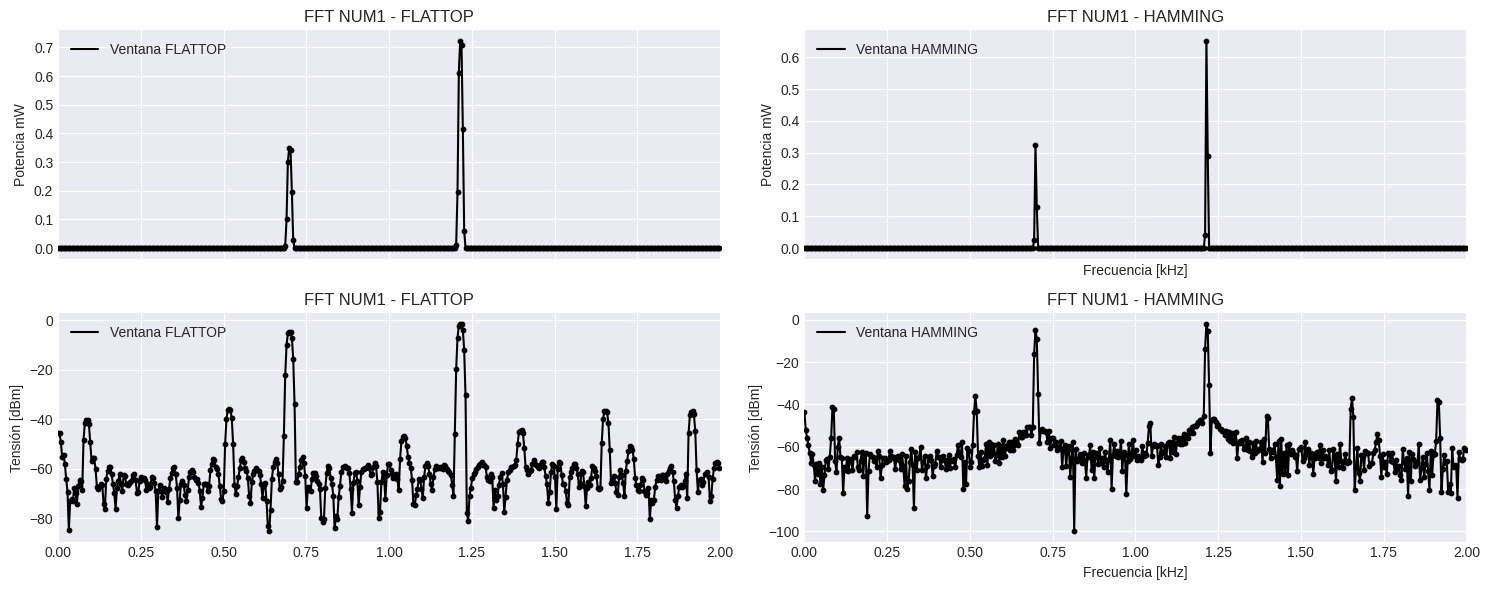 

La imagen anterior es el analisis espectral de Medidas Electronicas 1

### Conclusion

Podria ser que los valores de Welch no hayan dado tambien debido al uso de la ventana Hann, para que sea mas comparable habria que utilizar la ventana Blackman para que sea mas comparable.

Ya lo probe y no hay mejora, tendria que cambiar el nperseg en Welch y averiguar cual es el que mejor se ajusta, pero pareciera que Blackman-Tukey es el que mejor estima el valor.

Lo mas importante igualmente en este caso es poder estimar el ancho de banda de la señal para poder filtrar las señales indeseadas, sean ruido, canales adyacentes en una recepcion de una señal de RF, entre otras.

Se debe hacer un Trade Off entre resolucion espectral y varianza, para configurar correctamente nuestro estimador, por mi parte, de esta tarea semanal, sale que mi estimador favorito es Blackman.Tukey